# 04 - SARIMAX models

**Appliance energy forecasting**

**Inputs**

```text
data/processed/appliance_hourly.csv
outputs/metrics/benchmark_mase_scale.csv
outputs/metrics/benchmark_metrics_rolling.csv
```

**Outputs produced**

```text
outputs/metrics/sarimax_aic_grid.csv
outputs/metrics/sarimax_seasonal_grid.csv
outputs/metrics/sarimax_metrics_rolling.csv
outputs/metrics/sarimax_residual_tests.csv
outputs/forecasts/sarimax_forecasts_rolling.csv
outputs/forecasts/sarimax_forecast_24h.csv
outputs/model_objects/*_params.csv
outputs/figures/04_*.png
```

**A note on compute.** The required grid is 147 fits of a seasonal state-space model on
2,953 observations, which took roughly 35 minutes single-threaded on the machine used
here. Two forms of caching make the notebook re-runnable in seconds: the grid results are
written to CSV, and the estimated parameters of each fitted model are cached to
`outputs/model_objects/` so that re-running calls the Kalman filter instead of
re-optimising. Delete those files to force a fresh run. 

## 1. Setup

In [1]:
# 1. Imports

import warnings
warnings.filterwarnings("ignore")

import time

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 130)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# 2. Configuration

def find_project_root(markers=("data/raw", "data/processed", "notebooks"), start=None):
    """
    Locate the project root by walking up from the working directory.

    The root is the first ancestor containing any of `markers`, so this works on
    a fresh setup (before data/processed exists) as well as later, and does not
    depend on the notebook folder having a particular name.
    """

    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate

    raise FileNotFoundError(
        f"No project root found from {start} upwards.\n"
        f"Looked for: {markers}\n"
        "Expected layout:  <project>/notebooks/*.ipynb  and  <project>/data/raw/"
    )


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

FORECAST_DIR = OUTPUT_DIR / "forecasts"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "model_objects"

for path in [FORECAST_DIR, METRICS_DIR, FIGURE_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
rng = np.random.default_rng(RANDOM_STATE)

TARGET = "Appliances"

DAILY_PERIOD = 24
HORIZON = 24
TEST_STEPS = 14 * 24
N_WINDOWS = TEST_STEPS // HORIZON

# Grid required by the brief
P_RANGE = range(0, 7)
D_RANGE = range(0, 3)
Q_RANGE = range(0, 7)

# Seasonal order held fixed while the non-seasonal orders are searched
SEARCH_SEASONAL_ORDER = (1, 1, 1, DAILY_PERIOD)


def save_fig(fig, name, figure_dir=FIGURE_DIR):
    """Save a figure to outputs/figures and report the path."""

    path = figure_dir / name

    fig.savefig(path, dpi=200, bbox_inches="tight")

    print("Saved figure:", path)

    return path


print("Project root:", PROJECT_ROOT)

Project root: C:\Users\cjfin\Desktop\assignment 2


In [3]:
# 3. Load data and the evaluation settings 

data = pd.read_csv(
    PROCESSED_DIR / "appliance_hourly.csv",
    index_col=0,
    parse_dates=True,
).asfreq("h")

y = data[TARGET]

train = y.iloc[:-TEST_STEPS]
test = y.iloc[-TEST_STEPS:]

# The MASE scale is computed once in notebook 03 and reused everywhere, so that
# every model in the project is divided by the same constant.
SCALE = float(
    pd.read_csv(METRICS_DIR / "benchmark_mase_scale.csv", index_col=0).loc["mase_scale", "value"]
)

benchmark_metrics = pd.read_csv(METRICS_DIR / "benchmark_metrics_rolling.csv")

BEST_BENCHMARK = benchmark_metrics.iloc[0]["model"]
BEST_BENCHMARK_MASE = float(benchmark_metrics.iloc[0]["MASE"])

print("Train:", len(train), "hours | Test:", len(test), "hours")
print("MASE scale:", round(SCALE, 3), "Wh")
print("Benchmark to beat:", BEST_BENCHMARK, "with MASE", round(BEST_BENCHMARK_MASE, 3))

Train: 2953 hours | Test: 336 hours
MASE scale: 53.359 Wh
Benchmark to beat: seasonal_naive_weekly with MASE 0.804


In [4]:
# 4. Evaluation functions

def evaluate_forecast(name, y_true, y_pred, scale=None):
    """Compute MAE, RMSE, MASE and Bias for one forecast."""

    scale = SCALE if scale is None else scale

    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).reindex(y_true.index).astype(float)

    valid = y_true.notna() & y_pred.notna()

    errors = (y_pred[valid] - y_true[valid])

    return {
        "model": name,
        "n": int(valid.sum()),
        "MAE": float(np.mean(np.abs(errors))),
        "RMSE": float(np.sqrt(np.mean(errors ** 2))),
        "MASE": float(np.mean(np.abs(errors)) / scale),
        "Bias": float(np.mean(errors)),
    }

## 2. Stationarity assessment

In [5]:
# 5. ADF and KPSS on the level and differenced series

def stationarity_tests(series, name):
    """Run ADF and KPSS on a series and return a tidy one-row summary."""

    series = pd.Series(series).dropna()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag="AIC")
        kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")

    return {
        "series": name,
        "n": len(series),
        "ADF_stat": adf_stat,
        "ADF_p": adf_p,
        "ADF_says": "stationary" if adf_p < 0.05 else "unit root",
        "KPSS_stat": kpss_stat,
        "KPSS_p": kpss_p,
        "KPSS_says": "stationary" if kpss_p > 0.05 else "non-stationary",
    }


candidates = {
    "level (d=0, D=0)": y,
    "first difference (d=1)": y.diff(),
    "seasonal difference (D=1, s=24)": y.diff(DAILY_PERIOD),
    "both (d=1, D=1)": y.diff(DAILY_PERIOD).diff(),
}

tests = pd.DataFrame(
    [stationarity_tests(series, name) for name, series in candidates.items()]
).set_index("series")

tests.round(4)

,n,ADF_stat,ADF_p,ADF_says,KPSS_stat,KPSS_p,KPSS_says
series,,,,,,,
"level (d=0, D=0)",3289,-9.0846,0.0,stationary,0.0413,0.1,stationary
first difference (d=1),3288,-16.9344,0.0,stationary,0.0203,0.1,stationary
"seasonal difference (D=1, s=24)",3265,-13.6427,0.0,stationary,0.0073,0.1,stationary
"both (d=1, D=1)",3264,-17.9943,0.0,stationary,0.0436,0.1,stationary


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\04_stationarity_acf.png


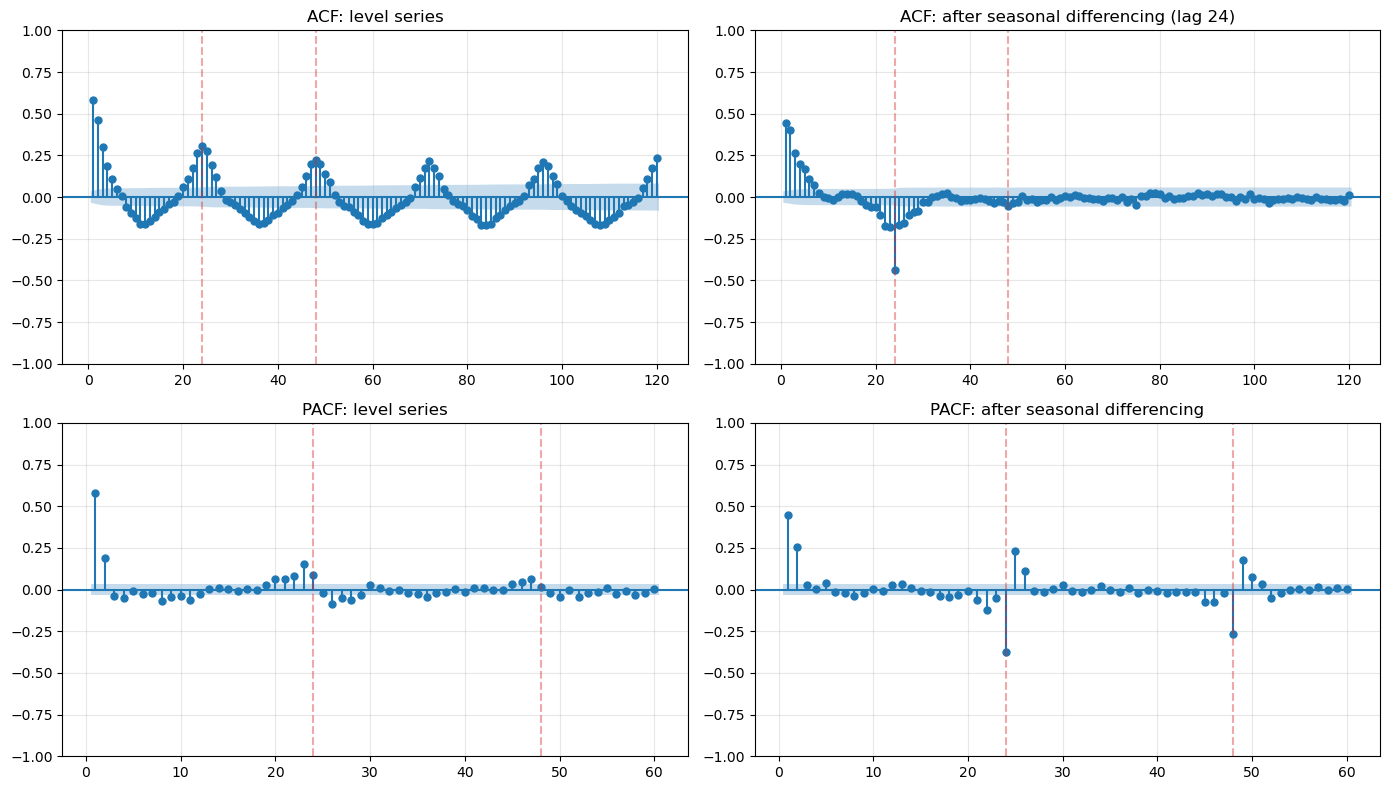

ACF at lag 24, level series      : 0.304
ACF at lag 24, seasonally diffed : -0.439


In [6]:
# 6. ACF before and after seasonal differencing

seasonal_diff = y.diff(DAILY_PERIOD).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(y, lags=120, ax=axes[0, 0], zero=False)
axes[0, 0].set_title("ACF: level series")

plot_acf(seasonal_diff, lags=120, ax=axes[0, 1], zero=False)
axes[0, 1].set_title("ACF: after seasonal differencing (lag 24)")

plot_pacf(y, lags=60, ax=axes[1, 0], method="ywm", zero=False)
axes[1, 0].set_title("PACF: level series")

plot_pacf(seasonal_diff, lags=60, ax=axes[1, 1], method="ywm", zero=False)
axes[1, 1].set_title("PACF: after seasonal differencing")

for ax in axes.ravel():
    ax.axvline(24, color="tab:red", linestyle="--", alpha=0.4)
    ax.axvline(48, color="tab:red", linestyle="--", alpha=0.4)

fig.tight_layout()
save_fig(fig, "04_stationarity_acf.png")

plt.show()

print("ACF at lag 24, level series      :", round(float(acf(y, nlags=25)[24]), 3))
print("ACF at lag 24, seasonally diffed :", round(float(acf(seasonal_diff, nlags=25)[24]), 3))

## 3. Order selection by AIC (Part 4, bullet 4)

In [7]:
# 7. One fit for the grid

def fit_for_grid(order, y_train, seasonal_order=SEARCH_SEASONAL_ORDER, maxiter=50):
    """
    Fit one candidate model and return a summary row.

    Speed settings:
        concentrate_scale   - the error variance is profiled out of the likelihood
        simple_differencing - differences are applied directly rather than modelled
                              in the state space

    A constant is included only when d = 0; with differencing a constant becomes a
    drift term, which the stationarity tests give no reason to include.

    Failures are recorded rather than raised, so that one bad order does not stop
    a search of 147 models.
    """

    p, d, q = order

    started = time.time()

    row = {
        "p": p, "d": d, "q": q,
        "P": seasonal_order[0], "D": seasonal_order[1],
        "Q": seasonal_order[2], "s": seasonal_order[3],
        "n_params": np.nan, "nobs": np.nan,
        "aic": np.nan, "bic": np.nan, "hqic": np.nan,
        "converged": False, "seconds": np.nan, "error": "",
    }

    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c" if d == 0 else "n",
            enforce_stationarity=False,
            enforce_invertibility=False,
            concentrate_scale=True,
            simple_differencing=True,
        )

        result = model.fit(disp=False, maxiter=maxiter)

        row.update({
            "n_params": int(len(result.params)),
            "nobs": int(result.nobs),
            "aic": float(result.aic),
            "bic": float(result.bic),
            "hqic": float(result.hqic),
            "converged": bool(result.mle_retvals.get("converged", False)),
        })

    except Exception as exc:
        row["error"] = f"{type(exc).__name__}: {exc}"[:120]

    row["seconds"] = time.time() - started

    return row

In [8]:
# 8. Run (or load) the full 7 x 3 x 7 grid

GRID_CACHE = METRICS_DIR / "sarimax_aic_grid.csv"


def run_pdq_grid(y_train, cache=GRID_CACHE, force=False):
    """
    Search every (p, d, q) combination required by the brief.

    Results are cached to CSV and reused unless force=True, because the full
    search takes roughly 35 minutes single-threaded.

    To parallelise on a multi-core machine, replace the loop with:

        from joblib import Parallel, delayed
        rows = Parallel(n_jobs=-1)(delayed(fit_for_grid)(o, y_train) for o in orders)

    statsmodels is CPU-only, so cores are what matter here, not a GPU.
    """

    orders = [(p, d, q) for p in P_RANGE for d in D_RANGE for q in Q_RANGE]

    if cache.exists() and not force:
        grid = pd.read_csv(cache)

        if len(grid) == len(orders):
            print(f"Loaded cached grid ({len(grid)} fits) from {cache.name}")
            return grid

        print(f"Cache has {len(grid)}/{len(orders)} fits; completing the remainder.")

        done = set(zip(grid["p"], grid["d"], grid["q"]))
        rows = grid.to_dict("records")
    else:
        done = set()
        rows = []

    started = time.time()

    for i, order in enumerate(orders, start=1):
        if order in done:
            continue

        rows.append(fit_for_grid(order, y_train))

        pd.DataFrame(rows).to_csv(cache, index=False)

        if i % 10 == 0:
            print(f"  {i}/{len(orders)} fitted, {time.time() - started:.0f}s elapsed")

    grid = pd.DataFrame(rows)

    print(f"Grid complete: {len(grid)} fits in {time.time() - started:.0f}s")

    return grid


grid = run_pdq_grid(train)

print("\nFits attempted :", len(grid))
print("Converged      :", int(grid["converged"].sum()))
print("Failed to fit  :", int(grid["aic"].isna().sum()))
print("Total fit time :", round(grid["seconds"].sum() / 60, 1), "minutes")

Loaded cached grid (147 fits) from sarimax_aic_grid.csv

Fits attempted : 147
Converged      : 99
Failed to fit  : 0
Total fit time : 38.9 minutes


In [9]:
# 9. The ranking the brief asks for, and its caveats

ranked = grid.sort_values("aic")

print("Top 10 by AIC across the whole grid:\n")
print(
    ranked.head(10)[["p", "d", "q", "aic", "bic", "n_params", "nobs", "converged"]]
    .to_string(index=False)
)

print("\nObservations used at each differencing order (why AIC is not comparable across d):")
print(grid.groupby("d")["nobs"].agg(["min", "max"]).to_string())

print("\nBest AIC within each d:")
print(
    grid.loc[grid.groupby("d")["aic"].idxmin()][["d", "p", "q", "aic", "converged"]]
    .to_string(index=False)
)

Top 10 by AIC across the whole grid:

 p  d  q          aic          bic  n_params  nobs  converged
 5  0  6 32154.146449 32243.723091        14  2929      False
 6  0  6 32156.218440 32251.766858        15  2929      False
 1  0  6 32158.615244 32224.304781        10  2929       True
 2  0  6 32160.445851 32232.107164        11  2929       True
 1  1  6 32161.404891 32221.119201         9  2928      False
 3  0  6 32162.208378 32239.841467        12  2929       True
 2  1  6 32162.554317 32228.240058        10  2928       True
 6  0  4 32163.014264 32246.623959        13  2929      False
 5  0  5 32163.234715 32246.844410        13  2929      False
 4  0  6 32163.944836 32247.549702        13  2929       True

Observations used at each differencing order (why AIC is not comparable across d):
    min   max
d            
0  2929  2929
1  2928  2928
2  2927  2927

Best AIC within each d:
 d  p  q          aic  converged
 0  5  6 32154.146449      False
 1  1  6 32161.404891      False
 2

In [10]:
# 10. Select among converged fits only

converged = grid[grid["converged"]].copy()

best_aic_row = converged.nsmallest(1, "aic").iloc[0]
best_bic_row = converged.nsmallest(1, "bic").iloc[0]

BEST_ORDER = (int(best_aic_row["p"]), int(best_aic_row["d"]), int(best_aic_row["q"]))

print("Best by AIC over the whole grid, ignoring convergence:")
print(" ", tuple(ranked.iloc[0][["p", "d", "q"]].astype(int)),
      "AIC", round(ranked.iloc[0]["aic"], 1),
      "| converged:", bool(ranked.iloc[0]["converged"]))

print("\nBest by AIC among converged fits:")
print(" ", BEST_ORDER, "AIC", round(best_aic_row["aic"], 1),
      "| parameters:", int(best_aic_row["n_params"]))

print("\nBest by BIC among converged fits:")
print(" ", tuple(best_bic_row[["p", "d", "q"]].astype(int)),
      "BIC", round(best_bic_row["bic"], 1),
      "| parameters:", int(best_bic_row["n_params"]))

print("\nAIC spread among the top 10 converged fits:",
      round(converged.nsmallest(10, "aic")["aic"].max()
            - converged.nsmallest(10, "aic")["aic"].min(), 1), "units")

print("Selected non-seasonal order:", BEST_ORDER)

Best by AIC over the whole grid, ignoring convergence:
  (5, 0, 6) AIC 32154.1 | converged: False

Best by AIC among converged fits:
  (1, 0, 6) AIC 32158.6 | parameters: 10

Best by BIC among converged fits:
  (1, 0, 6) BIC 32224.3 | parameters: 10

AIC spread among the top 10 converged fits: 9.6 units
Selected non-seasonal order: (1, 0, 6)


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\04_aic_surface.png


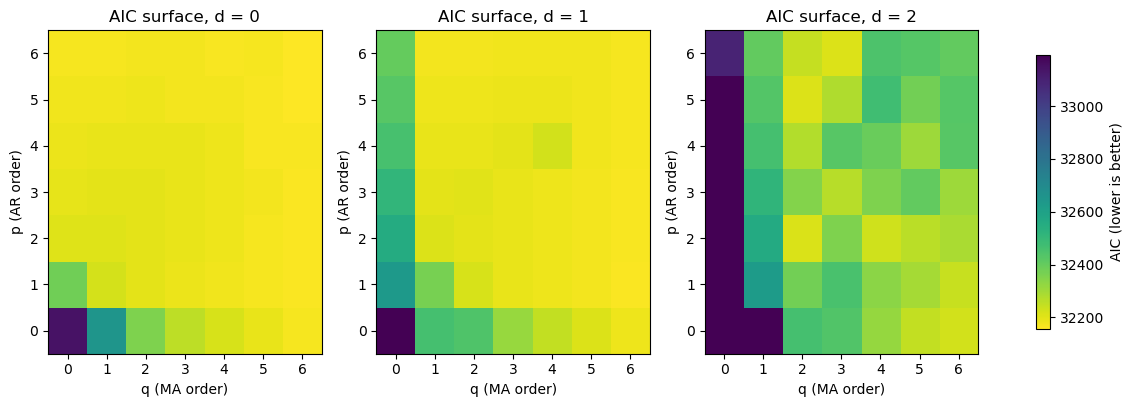

In [11]:
# 11. Visualise the AIC surface

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

vmin = grid["aic"].min()
vmax = grid["aic"].quantile(0.95)

for ax, d_value in zip(axes, sorted(grid["d"].unique())):
    subset = grid[grid["d"] == d_value].pivot(index="p", columns="q", values="aic")

    mesh = ax.imshow(subset.values, origin="lower", cmap="viridis_r",
                     vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_xticks(range(len(subset.columns)), subset.columns)
    ax.set_yticks(range(len(subset.index)), subset.index)
    ax.set_xlabel("q (MA order)")
    ax.set_ylabel("p (AR order)")
    ax.set_title(f"AIC surface, d = {d_value}")
    ax.grid(False)

fig.colorbar(mesh, ax=axes, label="AIC (lower is better)", shrink=0.85)

save_fig(fig, "04_aic_surface.png")

plt.show()

## 4. Seasonal order selection

In [12]:
# 12. Search the seasonal orders

SEASONAL_CACHE = METRICS_DIR / "sarimax_seasonal_grid.csv"


def run_seasonal_grid(y_train, order, cache=SEASONAL_CACHE, force=False):
    """Search (P, D, Q) in {0,1}^3 at s=24, holding the non-seasonal order fixed."""

    if cache.exists() and not force:
        seasonal = pd.read_csv(cache)

        matches_order = (
            (seasonal["p"] == order[0]).all()
            and (seasonal["d"] == order[1]).all()
            and (seasonal["q"] == order[2]).all()
        )

        if matches_order and len(seasonal) == 8:
            print("Loaded cached seasonal grid from", cache.name)
            return seasonal

        print("Cached seasonal grid does not match the selected order; refitting.")

    rows = []

    for P in (0, 1):
        for D in (0, 1):
            for Q in (0, 1):
                rows.append(
                    fit_for_grid(order, y_train, seasonal_order=(P, D, Q, DAILY_PERIOD))
                )

    seasonal = pd.DataFrame(rows)
    seasonal.to_csv(cache, index=False)

    return seasonal


seasonal_grid = run_seasonal_grid(train, BEST_ORDER)

print()
print(
    seasonal_grid
    .sort_values("aic")[["P", "D", "Q", "aic", "bic", "n_params", "nobs", "converged"]]
    .to_string(index=False)
)

Loaded cached seasonal grid from sarimax_seasonal_grid.csv

 P  D  Q          aic          bic  n_params  nobs  converged
 0  1  1 32156.899874 32216.617635         9  2929       True
 1  1  1 32158.615244 32224.304781        10  2929       True
 1  0  1 32573.756536 32639.536795        10  2953       True
 0  0  1 32676.929931 32736.730167         9  2953       True
 1  0  0 32731.566388 32791.387136         9  2953       True
 0  0  0 33011.803314 33065.697147         8  2953       True
 1  1  0 33242.391258 33302.129701         9  2929       True
 0  1  0 34179.464661 34233.284873         8  2929       True


In [13]:
# 13. Choose the seasonal order

# D is fixed at 1 on the ACF evidence; AIC then chooses P and Q.
seasonal_d1 = seasonal_grid[(seasonal_grid["D"] == 1) & seasonal_grid["converged"]]

best_seasonal_row = seasonal_d1.nsmallest(1, "aic").iloc[0]

BEST_SEASONAL_ORDER = (
    int(best_seasonal_row["P"]),
    int(best_seasonal_row["D"]),
    int(best_seasonal_row["Q"]),
    DAILY_PERIOD,
)

print("Selected model:")
print("  order          =", BEST_ORDER)
print("  seasonal_order =", BEST_SEASONAL_ORDER)
print()
print("AIC gap to the next seasonal specification:",
      round(seasonal_d1.nsmallest(2, "aic")["aic"].diff().iloc[-1], 2), "units")
print("AIC penalty for dropping seasonal differencing (D=0):",
      round(seasonal_grid[seasonal_grid["D"] == 0]["aic"].min()
            - seasonal_d1["aic"].min(), 1), "units (not a like-for-like comparison)")

Selected model:
  order          = (1, 0, 6)
  seasonal_order = (0, 1, 1, 24)

AIC gap to the next seasonal specification: 1.72 units
AIC penalty for dropping seasonal differencing (D=0): 416.9 units (not a like-for-like comparison)


## 5. Fit the selected model

The selected model is refitted without `simple_differencing`, because forecasts and
confidence intervals must be produced on the original scale. To avoid the slow
optimisation this implies, the fast fit is used as a warm start: its parameters become the
starting values for the full fit. This cuts the fit time roughly in half and, in this
case, converts a non-converged fit into a converged one.

In [14]:
# 14. Fit with caching and a warm start

def fit_sarimax(y_train, order, seasonal_order, exog=None, name="sarimax",
                cache_dir=MODEL_DIR, force=False, maxiter=100):
    """
    Fit a SARIMAX model for forecasting, with caching and a warm start.

    Only the estimated *parameters* are cached, as a small CSV. Re-running the
    notebook then calls model.filter(params), which reruns the Kalman filter with
    those parameters in a few seconds instead of re-optimising for a minute or
    more. Pickling the fitted results object would also work but produces files of
    hundreds of megabytes, since it stores the full smoothed state.

    Delete the CSV in outputs/model_objects (or pass force=True) to refit.
    """

    cache_path = cache_dir / f"{name}_params.csv"

    model = SARIMAX(
        y_train, exog=exog, order=order, seasonal_order=seasonal_order,
        trend="c" if order[1] == 0 else "n",
        enforce_stationarity=False, enforce_invertibility=False,
    )

    if cache_path.exists() and not force:
        cached = pd.read_csv(cache_path, index_col=0)["value"]

        if list(cached.index) == list(model.param_names):
            print(f"Loaded cached parameters for '{name}' from {cache_path.name}")

            return model.filter(cached.values)

        print(f"Cached parameters for '{name}' do not match the specification; refitting.")

    started = time.time()

    # Fast fit to obtain sensible starting values.
    warm = SARIMAX(
        y_train, exog=exog, order=order, seasonal_order=seasonal_order,
        trend="c" if order[1] == 0 else "n",
        enforce_stationarity=False, enforce_invertibility=False,
        concentrate_scale=True, simple_differencing=True,
    ).fit(disp=False, maxiter=50)

    # concentrate_scale profiles out sigma2, so it must be supplied for the full fit.
    start_params = np.concatenate([warm.params, [float(np.var(warm.resid))]])

    try:
        result = model.fit(start_params=start_params, disp=False, maxiter=maxiter)
    except Exception:
        result = model.fit(disp=False, maxiter=maxiter)

    print(f"Fitted '{name}' in {time.time() - started:.0f}s | "
          f"AIC {result.aic:.1f} | converged: {result.mle_retvals.get('converged')}")

    pd.Series(result.params, index=model.param_names).to_frame("value").to_csv(cache_path)

    return result


sarima_fit = fit_sarimax(
    train,
    order=BEST_ORDER,
    seasonal_order=BEST_SEASONAL_ORDER,
    name="sarima_target_only",
)

Loaded cached parameters for 'sarima_target_only' from sarima_target_only_params.csv


In [15]:
# 15. Parameter estimates

params = pd.DataFrame({
    "coefficient": sarima_fit.params,
    "std_err": sarima_fit.bse,
    "z": sarima_fit.tvalues,
    "p_value": sarima_fit.pvalues,
})

params["significant_5pct"] = params["p_value"] < 0.05

print(params.round(4).to_string())

print("\nLog-likelihood:", round(sarima_fit.llf, 1))
print("AIC:", round(sarima_fit.aic, 1), "| BIC:", round(sarima_fit.bic, 1))

           coefficient  std_err         z  p_value  significant_5pct
intercept      -0.0262   0.0848   -0.3089   0.7574             False
ar.L1           0.6357   0.1330    4.7800   0.0000              True
ma.L1          -0.2718   0.1326   -2.0501   0.0404              True
ma.L2           0.1319   0.0498    2.6507   0.0080              True
ma.L3           0.0011   0.0512    0.0209   0.9834             False
ma.L4           0.0191   0.0337    0.5672   0.5706             False
ma.L5           0.0298   0.0271    1.0983   0.2721             False
ma.L6           0.0124   0.0272    0.4560   0.6484             False
ma.S.L24       -0.9531   0.0057 -166.6543   0.0000              True
sigma2       3753.2279  54.3533   69.0524   0.0000              True

Log-likelihood: -16058.8
AIC: 32137.6 | BIC: 32197.3


## 6. Residual diagnostics

If the model has captured the structure, the residuals should be white noise: no
autocorrelation, constant variance, and ideally a symmetric distribution. 

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\04_residual_diagnostics.png


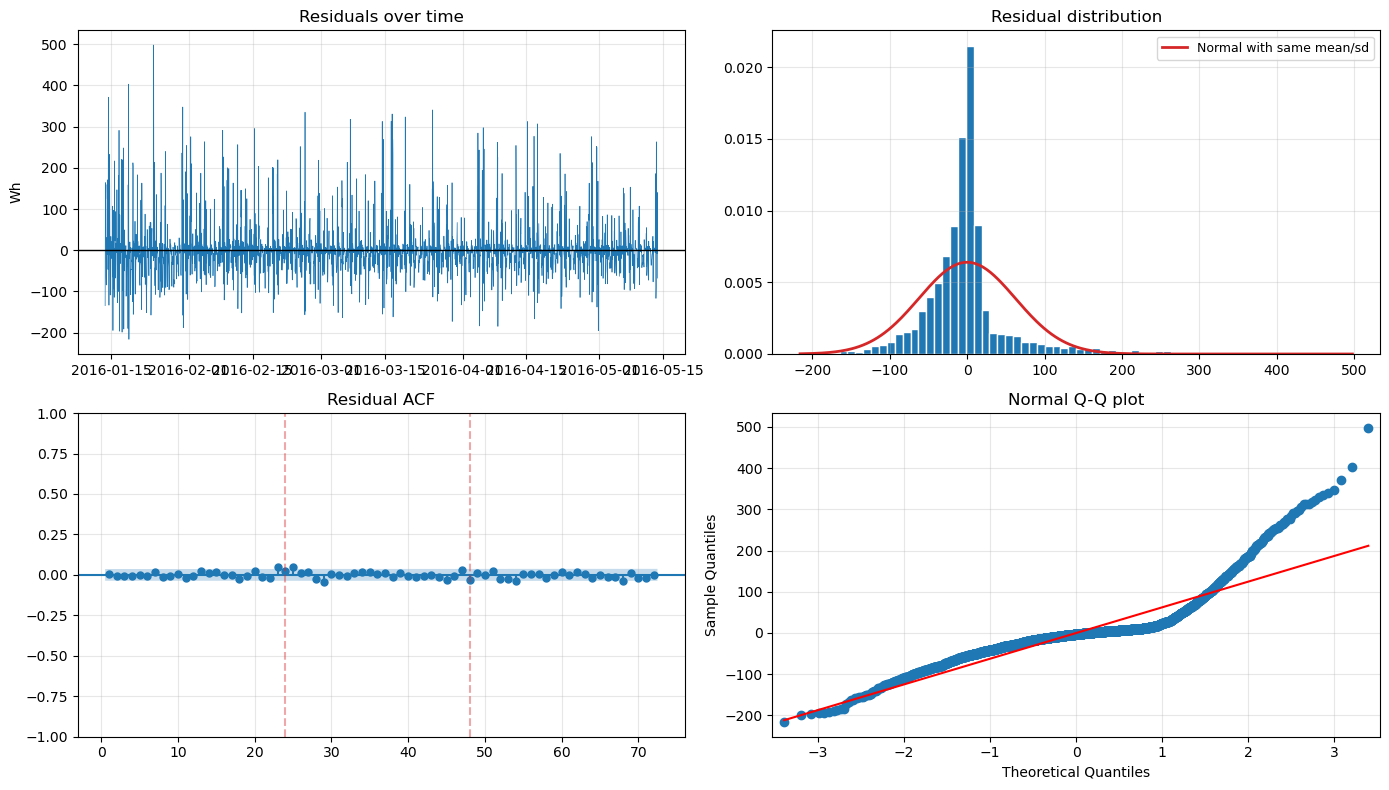

In [16]:
# 16. Residual ACF and distribution

residuals = pd.Series(sarima_fit.resid, index=train.index)

# The first few residuals reflect state-space initialisation, not model fit.
residuals = residuals.iloc[DAILY_PERIOD * 2:]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(residuals.index, residuals.values, linewidth=0.5, color="tab:blue")
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_title("Residuals over time")
axes[0, 0].set_ylabel("Wh")

axes[0, 1].hist(residuals.values, bins=70, density=True,
                color="tab:blue", edgecolor="white")

grid_x = np.linspace(residuals.min(), residuals.max(), 300)
normal_pdf = (
    np.exp(-0.5 * ((grid_x - residuals.mean()) / residuals.std()) ** 2)
    / (residuals.std() * np.sqrt(2 * np.pi))
)
axes[0, 1].plot(grid_x, normal_pdf, color="tab:red", linewidth=2,
                label="Normal with same mean/sd")
axes[0, 1].set_title("Residual distribution")
axes[0, 1].legend(fontsize=9)

plot_acf(residuals.values, lags=72, ax=axes[1, 0], zero=False)
axes[1, 0].set_title("Residual ACF")
axes[1, 0].axvline(24, color="tab:red", linestyle="--", alpha=0.4)
axes[1, 0].axvline(48, color="tab:red", linestyle="--", alpha=0.4)

qqplot(residuals.values, line="s", ax=axes[1, 1])
axes[1, 1].set_title("Normal Q-Q plot")

fig.tight_layout()
save_fig(fig, "04_residual_diagnostics.png")

plt.show()

In [17]:
# 17. Formal residual tests

ljung = acorr_ljungbox(residuals, lags=[24, 48, 168], return_df=True)

jb_stat, jb_p, skew, kurtosis = jarque_bera(residuals.values)

# Compare residual variance in the first and last thirds as a crude
# heteroskedasticity check.
first_third = residuals.iloc[: len(residuals) // 3]
last_third = residuals.iloc[-len(residuals) // 3:]

residual_tests = pd.Series({
    "mean_residual": residuals.mean(),
    "residual_sd": residuals.std(),
    "skew": skew,
    "kurtosis": kurtosis,
    "ljung_box_p_lag24": ljung.loc[24, "lb_pvalue"],
    "ljung_box_p_lag48": ljung.loc[48, "lb_pvalue"],
    "ljung_box_p_lag168": ljung.loc[168, "lb_pvalue"],
    "jarque_bera_p": jb_p,
    "var_ratio_last_vs_first_third": last_third.var() / first_third.var(),
    "significant_acf_lags_1_to_48": int(
        np.sum(np.abs(acf(residuals.values, nlags=48)[1:]) > 1.96 / np.sqrt(len(residuals)))
    ),
})

print(residual_tests.round(4).to_string())

residual_tests.to_frame("value").to_csv(METRICS_DIR / "sarimax_residual_tests.csv")

mean_residual                    -0.0689
residual_sd                      62.3644
skew                              1.8841
kurtosis                         11.2470
ljung_box_p_lag24                 0.7199
ljung_box_p_lag48                 0.4903
ljung_box_p_lag168                0.1495
jarque_bera_p                     0.0000
var_ratio_last_vs_first_third     0.6555
significant_acf_lags_1_to_48      3.0000


## 7. Exogenous variables

In [18]:
# 18. Build the exogenous design matrices

def make_calendr_features(index, n_harmonics=2):
    """
    Fourier terms for the daily and weekly cycles.

    These are deterministic functions of the timestamp, so they are known
    arbitrarily far into the future and are safe for genuine forecasting.
    """

    out = pd.DataFrame(index=index)

    hour = index.hour.values
    dow = index.dayofweek.values

    for k in range(1, n_harmonics + 1):
        out[f"hour_sin_{k}"] = np.sin(2 * np.pi * k * hour / 24)
        out[f"hour_cos_{k}"] = np.cos(2 * np.pi * k * hour / 24)

    out["dow_sin_1"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos_1"] = np.cos(2 * np.pi * dow / 7)

    out["is_weekend"] = (dow >= 5).astype(float)

    return out


WEATHER_COLS = ["T_out", "RH_out", "Windspeed", "Visibility", "Tdewpoint"]

calendar = make_calendar_features(data.index)
weather = data[WEATHER_COLS]

# Standardise the weather variables using training statistics only.
weather_mean = weather.iloc[:-TEST_STEPS].mean()
weather_std = weather.iloc[:-TEST_STEPS].std()

weather_scaled = (weather - weather_mean) / weather_std

exog_calendar = calendar
exog_full = pd.concat([calendar, weather_scaled], axis=1)

print("Calendar exogenous columns:", exog_calendar.shape[1])
print("Calendar + weather columns:", exog_full.shape[1])
print("\nWeather standardised with training means:")
print(weather_mean.round(2).to_string())

exog_full.head(3).round(3)

Calendar exogenous columns: 7
Calendar + weather columns: 12

Weather standardised with training means:
T_out          6.79
RH_out        80.14
Windspeed      4.12
Visibility    38.55
Tdewpoint      3.23


,hour_sin_1,hour_cos_1,hour_sin_2,hour_cos_2,dow_sin_1,dow_cos_1,is_weekend,T_out,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,
2016-01-11 17:00:00,-0.966,-0.259,0.5,-0.866,0.0,1.0,0.0,-0.094,0.808,0.825,1.311,0.463
2016-01-11 18:00:00,-1.000,-0.000,0.0,-1.000,0.0,1.0,0.0,-0.166,0.779,0.522,0.128,0.364
2016-01-11 19:00:00,-0.966,0.259,-0.5,-0.866,0.0,1.0,0.0,-0.155,0.655,0.758,0.128,0.296


In [19]:
# 19. Fit the two exogenous variants

sarimax_calendar_fit = fit_sarimax(
    train,
    order=BEST_ORDER,
    seasonal_order=BEST_SEASONAL_ORDER,
    exog=exog_calendar.iloc[:-TEST_STEPS],
    name="sarimax_calendar",
)

sarimax_weather_fit = fit_sarimax(
    train,
    order=BEST_ORDER,
    seasonal_order=BEST_SEASONAL_ORDER,
    exog=exog_full.iloc[:-TEST_STEPS],
    name="sarimax_calendar_weather",
)

Loaded cached parameters for 'sarimax_calendar' from sarimax_calendar_params.csv
Loaded cached parameters for 'sarimax_calendar_weather' from sarimax_calendar_weather_params.csv


Loaded cached parameters for 'sarimax_calendar_weather' from sarimax_calendar_weather_params.csv


In [20]:
# 20. Do the exogenous variables earn their place?

fit_comparison = pd.DataFrame([
    {"model": "sarima_target_only", "n_exog": 0,
     "aic": sarima_fit.aic, "bic": sarima_fit.bic, "llf": sarima_fit.llf},
    {"model": "sarimax_calendar", "n_exog": exog_calendar.shape[1],
     "aic": sarimax_calendar_fit.aic, "bic": sarimax_calendar_fit.bic,
     "llf": sarimax_calendar_fit.llf},
    {"model": "sarimax_calendar_weather", "n_exog": exog_full.shape[1],
     "aic": sarimax_weather_fit.aic, "bic": sarimax_weather_fit.bic,
     "llf": sarimax_weather_fit.llf},
])

print(fit_comparison.round(1).to_string(index=False))

exog_names = list(exog_full.columns)

exog_params = pd.DataFrame({
    "coefficient": sarimax_weather_fit.params[exog_names],
    "std_err": sarimax_weather_fit.bse[exog_names],
    "p_value": sarimax_weather_fit.pvalues[exog_names],
})

exog_params["significant_5pct"] = exog_params["p_value"] < 0.05

print("\nExogenous coefficients in the full model:")
print(exog_params.round(4).to_string())

                   model  n_exog     aic     bic      llf
      sarima_target_only       0 32137.6 32197.3 -16058.8
        sarimax_calendar       7 32146.5 32248.0 -16056.2
sarimax_calendar_weather      12 32154.1 32285.5 -16055.1

Exogenous coefficients in the full model:
            coefficient     std_err  p_value  significant_5pct
hour_sin_1      -0.0004  57109.5645   1.0000             False
hour_cos_1      -0.0005  23893.4419   1.0000             False
hour_sin_2       0.0003  45626.1013   1.0000             False
hour_cos_2      -0.0002  22553.2330   1.0000             False
dow_sin_1      -17.9164      6.4521   0.0055              True
dow_cos_1        4.9252      3.9318   0.2103             False
is_weekend     -21.6992      9.4517   0.0217              True
T_out          -33.2136     24.0947   0.1681             False
RH_out         -17.3848     14.6140   0.2342             False
Windspeed        2.5206      2.7970   0.3675             False
Visibility      -0.4739      1.5

## 8. Forecasting 24 hours ahead with confidence intervals

In [21]:
# 21. A single 24-hour forecast from the end of the training data

first_window = test.index[:HORIZON]

forecast_object = sarima_fit.get_forecast(steps=HORIZON)

point = forecast_object.predicted_mean
point.index = first_window

ci_80 = forecast_object.conf_int(alpha=0.20)
ci_95 = forecast_object.conf_int(alpha=0.05)

ci_80.index = first_window
ci_95.index = first_window

forecast_24h = pd.DataFrame({
    "actual": test.loc[first_window],
    "forecast": point,
    "lower_80": ci_80.iloc[:, 0].clip(lower=0),
    "upper_80": ci_80.iloc[:, 1],
    "lower_95": ci_95.iloc[:, 0].clip(lower=0),
    "upper_95": ci_95.iloc[:, 1],
})

print(evaluate_forecast("sarima_24h_single_window", forecast_24h["actual"], forecast_24h["forecast"]))

forecast_24h.round(1).head(8)

{'model': 'sarima_24h_single_window', 'n': 24, 'MAE': 21.25948390996065, 'RMSE': 31.70446646940953, 'MASE': 0.3984240348859997, 'Bias': -12.086285228643982}


,actual,forecast,lower_80,upper_80,lower_95,upper_95
date,,,,,,
2016-05-13 18:00:00,348.3,241.2,162.7,319.8,121.2,361.3
2016-05-13 19:00:00,208.3,161.2,77.7,244.8,33.4,289.0
2016-05-13 20:00:00,120.0,136.9,48.6,225.2,1.9,271.9
2016-05-13 21:00:00,63.3,94.6,4.4,184.7,0.0,232.4
2016-05-13 22:00:00,55.0,73.0,0.0,164.1,0.0,212.3
2016-05-13 23:00:00,61.7,61.3,0.0,153.0,0.0,201.5
2016-05-14 00:00:00,58.3,56.4,0.0,148.4,0.0,197.1
2016-05-14 01:00:00,63.3,54.9,0.0,147.1,0.0,195.9


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\04_forecast_24h_with_intervals.png


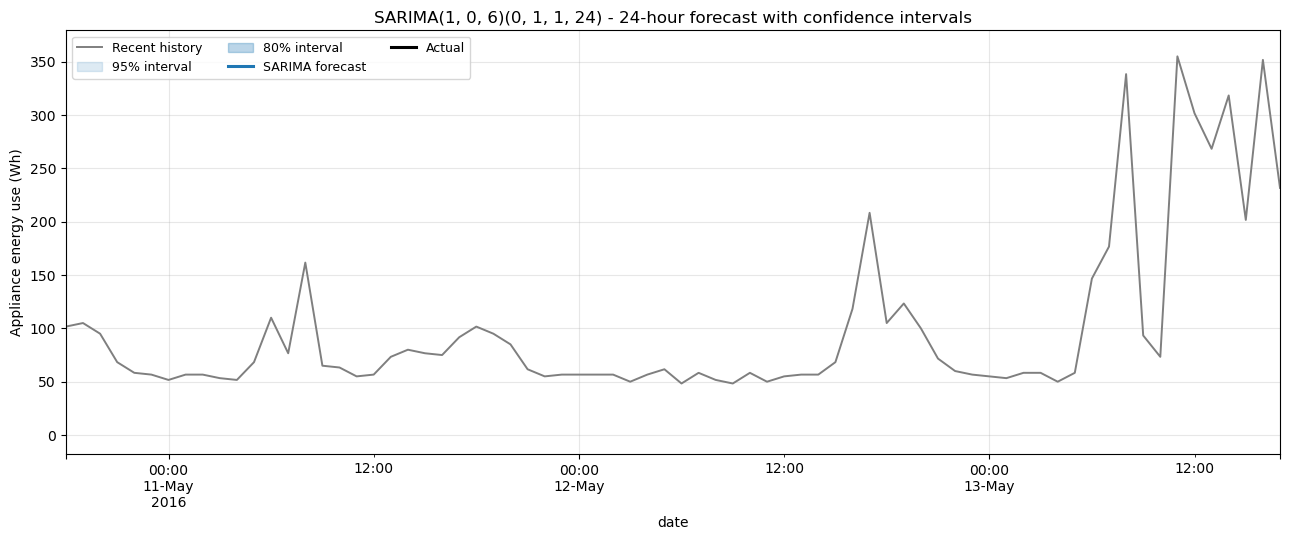

In [31]:
# 22. Plot the 24-hour forecast with its intervals

fig, ax = plt.subplots(figsize=(13, 5.5))

train.tail(72).plot(ax=ax, color="tab:grey", linewidth=1.4, label="Recent history")

ax.fill_between(forecast_24h.index, forecast_24h["lower_95"], forecast_24h["upper_95"],
                color="tab:blue", alpha=0.15, label="95% interval")
ax.fill_between(forecast_24h.index, forecast_24h["lower_80"], forecast_24h["upper_80"],
                color="tab:blue", alpha=0.30, label="80% interval")

ax.plot(forecast_24h.index, forecast_24h["forecast"], color="tab:blue",
        linewidth=2.2, label="SARIMA forecast")
ax.plot(forecast_24h.index, forecast_24h["actual"], color="black",
        linewidth=2.2, label="Actual")

ax.axvline(train.index.max(), color="tab:red", linestyle="--", alpha=0.7)

ax.set_title(f"SARIMA{BEST_ORDER}{BEST_SEASONAL_ORDER} - 24-hour forecast with confidence intervals")
ax.set_ylabel("Appliance energy use (Wh)")
ax.legend(ncol=3, fontsize=9)

fig.tight_layout()
save_fig(fig, "04_forecast_24h_with_intervals.png")

plt.show()

## 9. Rolling-origin evaluation 

In [23]:
# 23. Rolling forecasts with state updating

def rolling_sarimax_forecast(fitted, y_series, test_index, order, seasonal_order,
                             exog=None, horizon=HORIZON, name="sarimax"):
    """
    Rolling-origin forecasts using dynamic in-sample prediction.

    The model is filtered over the whole series with the parameters held at their
    training-set estimates, then each window is predicted with dynamic set to the
    window start, so that no observation from inside a window informs its own
    forecast.
    """

    full_model = SARIMAX(
        y_series, exog=exog, order=order, seasonal_order=seasonal_order,
        trend="c" if order[1] == 0 else "n",
        enforce_stationarity=False, enforce_invertibility=False,
    )

    state = full_model.filter(np.asarray(fitted.params))

    records = []

    n_windows = len(test_index) // horizon

    for window in range(n_windows):
        window_index = test_index[window * horizon:(window + 1) * horizon]

        prediction = state.get_prediction(
            start=window_index[0],
            end=window_index[-1],
            dynamic=window_index[0],
        )

        ci_80 = prediction.conf_int(alpha=0.20)
        ci_95 = prediction.conf_int(alpha=0.05)

        records.append(pd.DataFrame({
            "window": window + 1,
            "step": np.arange(1, horizon + 1),
            "actual": y_series.loc[window_index].values,
            name: prediction.predicted_mean.values,
            "lower_80": np.clip(ci_80.iloc[:, 0].values, 0, None),
            "upper_80": ci_80.iloc[:, 1].values,
            "lower_95": np.clip(ci_95.iloc[:, 0].values, 0, None),
            "upper_95": ci_95.iloc[:, 1].values,
        }, index=window_index))

    return pd.concat(records)


started = time.time()

rolling_sarima = rolling_sarimax_forecast(
    sarima_fit, y, test.index,
    order=BEST_ORDER, seasonal_order=BEST_SEASONAL_ORDER,
    name="sarima_target_only",
)

# Check that the first window reproduces a plain 24-step forecast from the
# training-only model: dynamic prediction is doing what it claims.
assert np.allclose(
    rolling_sarima["sarima_target_only"].values[:HORIZON],
    sarima_fit.get_forecast(steps=HORIZON).predicted_mean.values,
    atol=1e-6,
), "Dynamic prediction does not match a direct forecast from the training model"

rolling_calendar = rolling_sarimax_forecast(
    sarimax_calendar_fit, y, test.index,
    order=BEST_ORDER, seasonal_order=BEST_SEASONAL_ORDER,
    exog=exog_calendar, name="sarimax_calendar",
)

rolling_weather = rolling_sarimax_forecast(
    sarimax_weather_fit, y, test.index,
    order=BEST_ORDER, seasonal_order=BEST_SEASONAL_ORDER,
    exog=exog_full, name="sarimax_calendar_weather",
)

print(f"Rolling forecasts produced in {time.time() - started:.0f}s")

rolling_sarima.head(3).round(1)

Rolling forecasts produced in 22s


,window,step,actual,sarima_target_only,lower_80,upper_80,lower_95,upper_95
date,,,,,,,,
2016-05-13 18:00:00,1,1,348.3,241.2,162.7,319.8,121.2,361.3
2016-05-13 19:00:00,1,2,208.3,161.2,77.7,244.8,33.4,289.0
2016-05-13 20:00:00,1,3,120.0,136.9,48.6,225.2,1.9,271.9


In [24]:
# 24. Metrics, against the benchmarks from notebook 03

sarimax_forecasts = pd.DataFrame({
    "actual": rolling_sarima["actual"],
    "sarima_target_only": rolling_sarima["sarima_target_only"],
    "sarimax_calendar": rolling_calendar["sarimax_calendar"],
    "sarimax_calendar_weather": rolling_weather["sarimax_calendar_weather"],
})

sarimax_metrics = pd.DataFrame([
    evaluate_forecast(col, sarimax_forecasts["actual"], sarimax_forecasts[col])
    for col in sarimax_forecasts.columns
    if col != "actual"
])

combined = (
    pd.concat([sarimax_metrics, benchmark_metrics], ignore_index=True)
    .sort_values("MASE")
    .reset_index(drop=True)
)

print("Rolling-origin performance, SARIMAX models and benchmarks together:\n")
print(combined.round(3).to_string(index=False))

print(f"\nStrongest benchmark ({BEST_BENCHMARK}) MASE: {BEST_BENCHMARK_MASE:.3f}")
print(f"Best SARIMAX MASE: {sarimax_metrics['MASE'].min():.3f}")

Rolling-origin performance, SARIMAX models and benchmarks together:

                   model   n     MAE    RMSE  MASE    Bias
      sarima_target_only 336  36.785  64.205 0.689  -4.652
        sarimax_calendar 336  37.899  64.256 0.710  -4.993
sarimax_calendar_weather 336  38.372  64.742 0.719  -3.206
   seasonal_naive_weekly 336  42.922  79.668 0.804 -12.624
    seasonal_naive_daily 336  48.393  85.790 0.907   1.667
                    mean 336  50.010  73.986 0.937  -3.061
                   naive 336 143.383 170.623 2.687 114.673
                   drift 336 143.942 171.260 2.698 115.314

Strongest benchmark (seasonal_naive_weekly) MASE: 0.804
Best SARIMAX MASE: 0.689


In [25]:
# 25. Is any difference from the benchmark meaningful?

benchmark_rolling = pd.read_csv(
    FORECAST_DIR / "benchmark_forecasts_rolling.csv",
    index_col=0,
    parse_dates=True,
)


def bootstrap_mae_difference(errors_a, errors_b, n_boot=2000, rng=rng):
    """Percentile bootstrap CI for a difference in MAE, resampling 24-hour blocks."""

    a = np.abs(np.asarray(errors_a)).reshape(-1, HORIZON)
    b = np.abs(np.asarray(errors_b)).reshape(-1, HORIZON)

    observed = a.mean() - b.mean()

    draws = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, a.shape[0], a.shape[0])
        draws[i] = a[idx].mean() - b[idx].mean()

    return observed, *np.percentile(draws, [2.5, 97.5])


reference_errors = (
    benchmark_rolling[BEST_BENCHMARK] - benchmark_rolling["actual"]
).values

rows = []

for col in ["sarima_target_only", "sarimax_calendar", "sarimax_calendar_weather"]:
    observed, lower, upper = bootstrap_mae_difference(
        (sarimax_forecasts[col] - sarimax_forecasts["actual"]).values,
        reference_errors,
    )

    rows.append({
        "model": col,
        "MAE_vs_benchmark": observed,
        "ci_lower": lower,
        "ci_upper": upper,
        "verdict": (
            "clearly worse" if lower > 0
            else "clearly better" if upper < 0
            else "indistinguishable"
        ),
    })

print(f"MAE difference against {BEST_BENCHMARK}. Negative means SARIMAX is better.\n")
print(pd.DataFrame(rows).round(2).to_string(index=False))

MAE difference against seasonal_naive_weekly. Negative means SARIMAX is better.

                   model  MAE_vs_benchmark  ci_lower  ci_upper           verdict
      sarima_target_only             -6.14    -18.22      3.31 indistinguishable
        sarimax_calendar             -5.02    -15.66      4.18 indistinguishable
sarimax_calendar_weather             -4.55    -14.69      4.13 indistinguishable


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\04_sarimax_vs_benchmark_errors.png


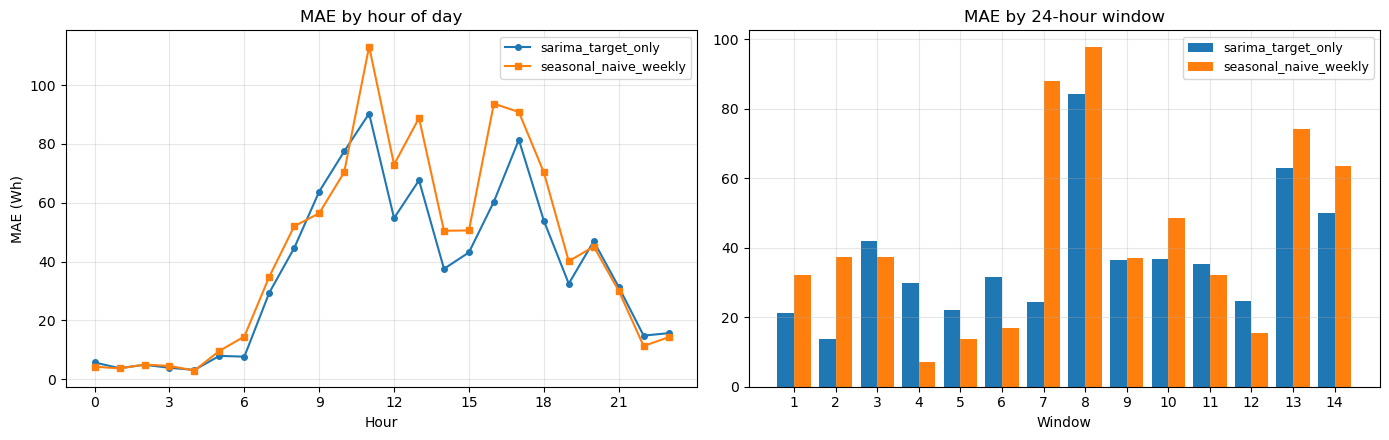

Windows in which SARIMAX beat the benchmark: 8 of 14


In [26]:
# 26. Where does SARIMAX do well or badly?

best_sarimax_col = sarimax_metrics.sort_values("MASE").iloc[0]["model"]

comparison_frame = pd.DataFrame({
    "actual": sarimax_forecasts["actual"],
    "sarimax": sarimax_forecasts[best_sarimax_col],
    "benchmark": benchmark_rolling[BEST_BENCHMARK],
})

comparison_frame["hour"] = comparison_frame.index.hour

by_hour = comparison_frame.groupby("hour").apply(
    lambda g: pd.Series({
        "sarimax": np.mean(np.abs(g["sarimax"] - g["actual"])),
        "benchmark": np.mean(np.abs(g["benchmark"] - g["actual"])),
    })
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(by_hour.index, by_hour["sarimax"], marker="o", markersize=4,
             label=best_sarimax_col)
axes[0].plot(by_hour.index, by_hour["benchmark"], marker="s", markersize=4,
             label=BEST_BENCHMARK)
axes[0].set_title("MAE by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("MAE (Wh)")
axes[0].set_xticks(range(0, 24, 3))
axes[0].legend(fontsize=9)

per_window = comparison_frame.groupby(rolling_sarima["window"]).apply(
    lambda g: pd.Series({
        "sarimax": np.mean(np.abs(g["sarimax"] - g["actual"])),
        "benchmark": np.mean(np.abs(g["benchmark"] - g["actual"])),
    })
)

x = np.arange(len(per_window))
axes[1].bar(x - 0.2, per_window["sarimax"], 0.4, label=best_sarimax_col)
axes[1].bar(x + 0.2, per_window["benchmark"], 0.4, label=BEST_BENCHMARK)
axes[1].set_title("MAE by 24-hour window")
axes[1].set_xlabel("Window")
axes[1].set_xticks(x, per_window.index)
axes[1].legend(fontsize=9)

fig.tight_layout()
save_fig(fig, "04_sarimax_vs_benchmark_errors.png")

plt.show()

print("Windows in which SARIMAX beat the benchmark:",
      int((per_window["sarimax"] < per_window["benchmark"]).sum()), "of", len(per_window))

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\04_sarimax_rolling_forecasts.png


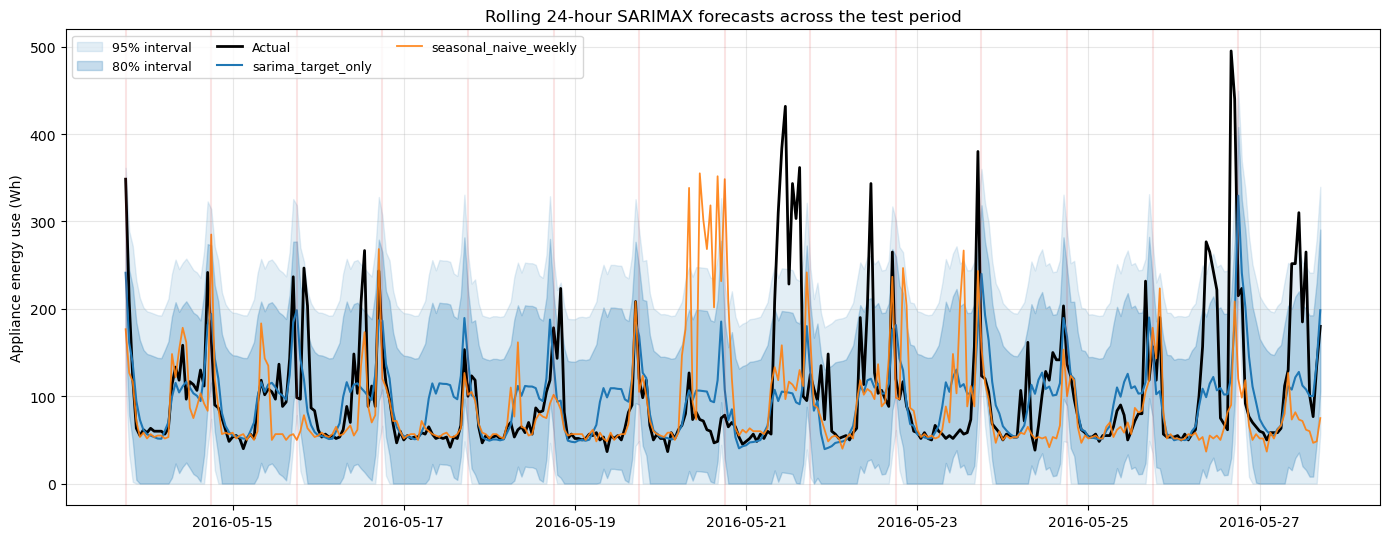

In [27]:
# 27. Rolling forecasts across the test period

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.fill_between(rolling_sarima.index, rolling_sarima["lower_95"], rolling_sarima["upper_95"],
                color="tab:blue", alpha=0.12, label="95% interval")
ax.fill_between(rolling_sarima.index, rolling_sarima["lower_80"], rolling_sarima["upper_80"],
                color="tab:blue", alpha=0.25, label="80% interval")

ax.plot(sarimax_forecasts.index, sarimax_forecasts["actual"], color="black",
        linewidth=2, label="Actual")
ax.plot(sarimax_forecasts.index, sarimax_forecasts[best_sarimax_col],
        color="tab:blue", linewidth=1.5, label=best_sarimax_col)
ax.plot(benchmark_rolling.index, benchmark_rolling[BEST_BENCHMARK],
        color="tab:orange", linewidth=1.3, alpha=0.9, label=BEST_BENCHMARK)

for origin in rolling_sarima.groupby("window").apply(lambda g: g.index.min()):
    ax.axvline(origin, color="tab:red", alpha=0.12)

ax.set_title("Rolling 24-hour SARIMAX forecasts across the test period")
ax.set_ylabel("Appliance energy use (Wh)")
ax.legend(ncol=3, fontsize=9)

fig.tight_layout()
save_fig(fig, "04_sarimax_rolling_forecasts.png")

plt.show()

## 10. Are the confidence intervals honest?

In [28]:
# 28. Interval coverage and width

def interval_summary(frame, actual_col="actual"):
    """Coverage and mean width of the 80% and 95% intervals."""

    actual = frame[actual_col]

    return pd.Series({
        "coverage_80": float(((actual >= frame["lower_80"]) & (actual <= frame["upper_80"])).mean()),
        "coverage_95": float(((actual >= frame["lower_95"]) & (actual <= frame["upper_95"])).mean()),
        "mean_width_80": float((frame["upper_80"] - frame["lower_80"]).mean()),
        "mean_width_95": float((frame["upper_95"] - frame["lower_95"]).mean()),
    })


benchmark_intervals = pd.read_csv(
    FORECAST_DIR / "benchmark_prediction_intervals.csv",
    index_col=0,
    parse_dates=True,
)

interval_comparison = pd.DataFrame({
    "sarima_gaussian": interval_summary(rolling_sarima),
    "benchmark_empirical": interval_summary(benchmark_intervals),
}).T

print("Nominal coverage is 0.80 and 0.95.\n")
print(interval_comparison.round(3).to_string())

# Where do the intervals fail? Below the lower bound, or above the upper?
below = (rolling_sarima["actual"] < rolling_sarima["lower_95"]).sum()
above = (rolling_sarima["actual"] > rolling_sarima["upper_95"]).sum()

print(f"\n95% interval breaches: {below} below the lower bound, {above} above the upper bound.")
print("An asymmetric pattern indicates the symmetric Gaussian interval is the wrong shape "
      "for a right-skewed series.")

Nominal coverage is 0.80 and 0.95.

                     coverage_80  coverage_95  mean_width_80  mean_width_95
sarima_gaussian            0.902        0.952        168.111        229.132
benchmark_empirical        0.851        0.976        154.356        250.205

95% interval breaches: 0 below the lower bound, 16 above the upper bound.
An asymmetric pattern indicates the symmetric Gaussian interval is the wrong shape for a right-skewed series.


## 11. Save outputs

In [29]:
# 29. Save forecasts and metrics

sarimax_rolling_out = sarimax_forecasts.copy()
sarimax_rolling_out["window"] = rolling_sarima["window"]
sarimax_rolling_out["step"] = rolling_sarima["step"]

for col in ["lower_80", "upper_80", "lower_95", "upper_95"]:
    sarimax_rolling_out[col] = rolling_sarima[col]

sarimax_rolling_out.to_csv(FORECAST_DIR / "sarimax_forecasts_rolling.csv")
forecast_24h.to_csv(FORECAST_DIR / "sarimax_forecast_24h.csv")
sarimax_metrics.to_csv(METRICS_DIR / "sarimax_metrics_rolling.csv", index=False)

selected_spec = pd.Series({
    "order": str(BEST_ORDER),
    "seasonal_order": str(BEST_SEASONAL_ORDER),
    "aic": sarima_fit.aic,
    "bic": sarima_fit.bic,
    "n_grid_fits": len(grid),
    "best_sarimax_model": best_sarimax_col,
})

selected_spec.to_frame("value").to_csv(METRICS_DIR / "sarimax_selected_model.csv")

for path in sorted(FORECAST_DIR.glob("sarimax_*")) + sorted(METRICS_DIR.glob("sarimax_*")):
    print("Saved:", path.relative_to(PROJECT_ROOT))

Saved: outputs\forecasts\sarimax_forecast_24h.csv
Saved: outputs\forecasts\sarimax_forecasts_rolling.csv
Saved: outputs\metrics\sarimax_aic_grid.csv
Saved: outputs\metrics\sarimax_metrics_rolling.csv
Saved: outputs\metrics\sarimax_residual_tests.csv
Saved: outputs\metrics\sarimax_seasonal_grid.csv
Saved: outputs\metrics\sarimax_selected_model.csv


In [30]:
# 30. Checks on the saved outputs

reloaded = pd.read_csv(
    FORECAST_DIR / "sarimax_forecasts_rolling.csv", index_col=0, parse_dates=True
)

assert len(reloaded) == TEST_STEPS
assert reloaded.index.equals(test.index)
assert reloaded["window"].nunique() == N_WINDOWS
assert reloaded[["sarima_target_only", "sarimax_calendar",
                 "sarimax_calendar_weather"]].isna().sum().sum() == 0
assert (reloaded["upper_95"] >= reloaded["lower_95"]).all()

print("Saved SARIMAX outputs verified:", len(reloaded), "rows,",
      reloaded["window"].nunique(), "windows.")

Saved SARIMAX outputs verified: 336 rows, 14 windows.
